In [1]:
# !pip install -q -U "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install -q --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes scikit-learn pandas tqdm

In [2]:
import torch
import pandas as pd
from tqdm import tqdm
from unsloth import FastLanguageModel
from sklearn.metrics import classification_report, f1_score, accuracy_score

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
max_seq_length = 1024
dtype = None
load_in_4bit = True

In [5]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-7b-it-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.1.3: Fast Gemma patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.57G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/154 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 3072, padding_idx=0)
    (layers): ModuleList(
      (0-27): 28 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=3072, bias=False)
          (rotary_emb): GemmaFixedRotaryEmbedding()
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=24576, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=24576, bias=False)
          (down_proj): Linear4bit(in_features=24576, out_features=3072, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((3072,), eps=1e-06)
        (post_attention_layernorm):

In [6]:
rusentitweet_test_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'
test_df = pd.read_csv(rusentitweet_test_path)
test_df.shape

(2679, 3)

In [7]:
label_map = {
    "neutral": 0,
    "positive": 1,
    "negative": 2
}

In [8]:
reverse_label_map = {v: k for k, v in label_map.items()}

In [9]:
prompt_template = """Проанализируй тональность следующего текста.
Текст может быть политическим, содержать сарказм или сленг.
Выбери ОДНУ категорию из трех: positive, negative, neutral.
Не пиши никаких объяснений. Только одно слово.

Текст: {}
Тональность:"""

In [10]:
predictions = []
ground_truth = []

In [11]:
print("Начинаем Zero-Shot инференс...")

for index, row in tqdm(test_df.iterrows(), total=test_df.shape[0]):
    text = row['text'] # Убедитесь, что имя колонки верное
    true_label = row['label'] # Убедитесь, что имя колонки верное

    # Формируем вход
    inputs = tokenizer(
        [prompt_template.format(text)],
        return_tensors="pt"
    ).to(device)

    # Генерация
    # max_new_tokens=10, так как нам нужно только одно слово
    outputs = model.generate(**inputs, max_new_tokens=10, use_cache=True, pad_token_id=tokenizer.eos_token_id)

    # Декодинг
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # Парсинг ответа (берем всё, что после "Тональность:")
    # Модель может вернуть "Тональность: positive", отрезаем лишнее
    answer = decoded.split("Тональность:")[-1].strip().lower()

    # Нормализация ответа (убираем пунктуацию, если модель добавила точку)
    answer = answer.strip(".").strip()

    # Простая эвристика для маппинга текстового ответа в класс
    pred_label = -1 # -1 будет означать "ошибка парсинга"

    if "positive" in answer or "позитив" in answer:
        pred_label = label_map["positive"]
    elif "negative" in answer or "негатив" in answer:
        pred_label = label_map["negative"]
    elif "neutral" in answer or "нейтраль" in answer:
        pred_label = label_map["neutral"]

    predictions.append(pred_label)
    ground_truth.append(true_label)

Начинаем Zero-Shot инференс...


100%|██████████| 2679/2679 [36:21<00:00,  1.23it/s]


In [13]:
test_df['gemma_zeroshot_pred'] = predictions
test_df['gemma_raw_answer'] = [a for a in predictions] # Можно сохранить сырой текст для дебага
test_df.to_csv("gemma_zeroshot_results.csv", index=False)
print("Результаты сохранены в gemma_zeroshot_results.csv")

Результаты сохранены в gemma_zeroshot_results.csv


In [15]:
# 1. Фильтруем ошибки генерации (-1)
valid_indices = [i for i, x in enumerate(predictions) if x != -1]
y_pred = [int(predictions[i]) for i in valid_indices] # Явно приводим к int
y_true_raw = [ground_truth[i] for i in valid_indices]

# 2. Нормализация Ground Truth (y_true)
# Проверяем, в каком формате пришли метки из CSV и приводим их к int (0, 1, 2)
y_true = []
for label in y_true_raw:
    if isinstance(label, int):
        y_true.append(label)
    elif isinstance(label, str):
        if label.isdigit(): # Если это строка "1"
            y_true.append(int(label))
        else: # Если это строка "positive" и т.д.
            # Маппинг должен совпадать с тем, что вы использовали для predictions
            # Проверьте, совпадают ли ключи с вашим CSV!
            mapping = {"neutral": 0, "positive": 1, "negative": 2, "skip": 0, "speech_act": 0}
            y_true.append(mapping.get(label.lower(), 0)) # Fallback на 0 (neutral) если метка странная
    else:
        y_true.append(0)

# 3. Вывод метрик
print(f"=== Результаты Gemma 7B Instruct (Zero-Shot) ===")
print(f"Failure Rate (невалидный формат ответа): {failure_rate:.2f}%")
print("-" * 60)

# Проверка на всякий случай, чтобы длины совпадали (хирургическая точность)
assert len(y_true) == len(y_pred), "Длины массивов не совпадают!"

# Теперь оба массива гарантированно int
print(classification_report(y_true, y_pred, target_names=["Neutral", "Positive", "Negative"], digits=4))

f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

print(f"Macro F1: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")

=== Результаты Gemma 7B Instruct (Zero-Shot) ===
Failure Rate (невалидный формат ответа): 22.36%
------------------------------------------------------------
              precision    recall  f1-score   support

     Neutral     0.7788    0.3662    0.4982      1125
    Positive     0.3404    0.7593    0.4700       403
    Negative     0.5077    0.5996    0.5498       552

    accuracy                         0.5043      2080
   macro avg     0.5423    0.5751    0.5060      2080
weighted avg     0.6219    0.5043    0.5064      2080

Macro F1: 0.5060
Accuracy: 0.5043


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

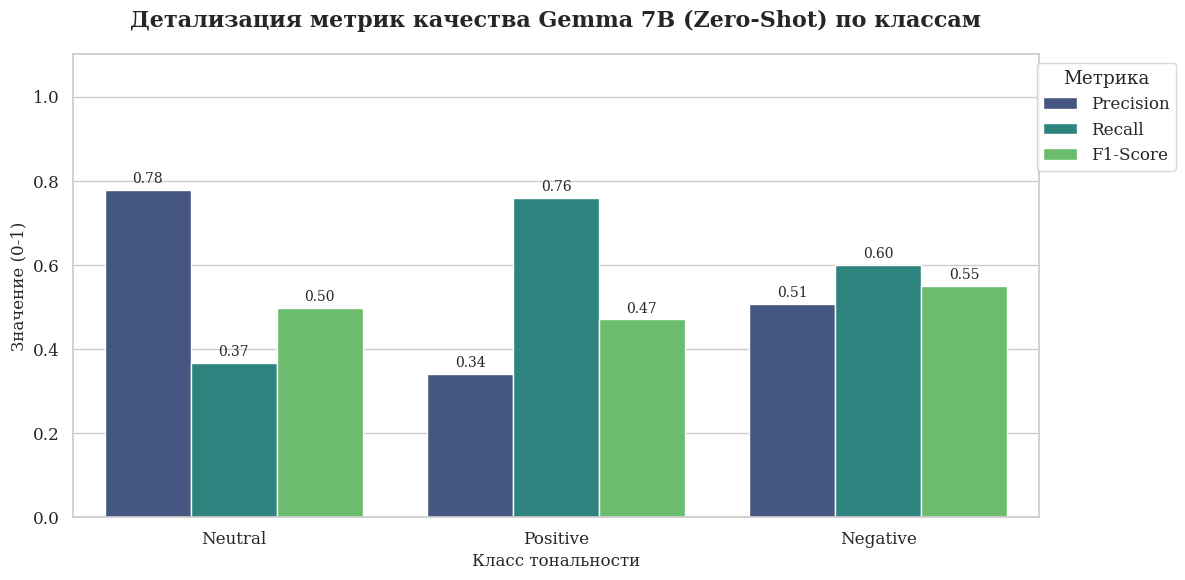

=== Сводная таблица (LaTeX format friendly) ===
Metric    F1-Score  Precision  Recall
Class                                
Negative    0.5498     0.5077  0.5996
Neutral     0.4982     0.7788  0.3662
Positive    0.4700     0.3404  0.7593


In [18]:
report_dict = classification_report(y_true, y_pred, target_names=["Neutral", "Positive", "Negative"], output_dict=True)

# 2. Преобразуем в DataFrame для Seaborn
# Исключаем служебные строки (accuracy, macro avg, weighted avg) для графика по классам
classes = ["Neutral", "Positive", "Negative"]
metrics_data = []

for cls in classes:
    metrics_data.append({
        "Class": cls,
        "Metric": "Precision",
        "Score": report_dict[cls]['precision']
    })
    metrics_data.append({
        "Class": cls,
        "Metric": "Recall",
        "Score": report_dict[cls]['recall']
    })
    metrics_data.append({
        "Class": cls,
        "Metric": "F1-Score",
        "Score": report_dict[cls]['f1-score']
    })

df_metrics = pd.DataFrame(metrics_data)

# 3. Настройка стиля (Академический)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'serif'

# 4. Построение графика
plt.figure(figsize=(12, 6))
chart = sns.barplot(data=df_metrics, x="Class", y="Score", hue="Metric", palette="viridis")

# 5. Тюнинг оформления
plt.title("Детализация метрик качества Gemma 7B (Zero-Shot) по классам", fontsize=16, pad=20, weight='bold')
plt.ylabel("Значение (0-1)", fontsize=12)
plt.xlabel("Класс тональности", fontsize=12)
plt.ylim(0, 1.1) # Оставляем место для легенды и подписей
plt.legend(title="Метрика", loc='upper right', bbox_to_anchor=(1.15, 1))

# 6. Добавление точных значений над столбцами (для читаемости в ч/б печати)
for container in chart.containers:
    chart.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.savefig('gemma_zeroshot_metrics_breakdown.png', dpi=300)
plt.show()

# Вывод сводной таблицы текстом для копирования в Word
print("=== Сводная таблица (LaTeX format friendly) ===")
df_pivot = df_metrics.pivot(index="Class", columns="Metric", values="Score")
print(df_pivot.round(4))

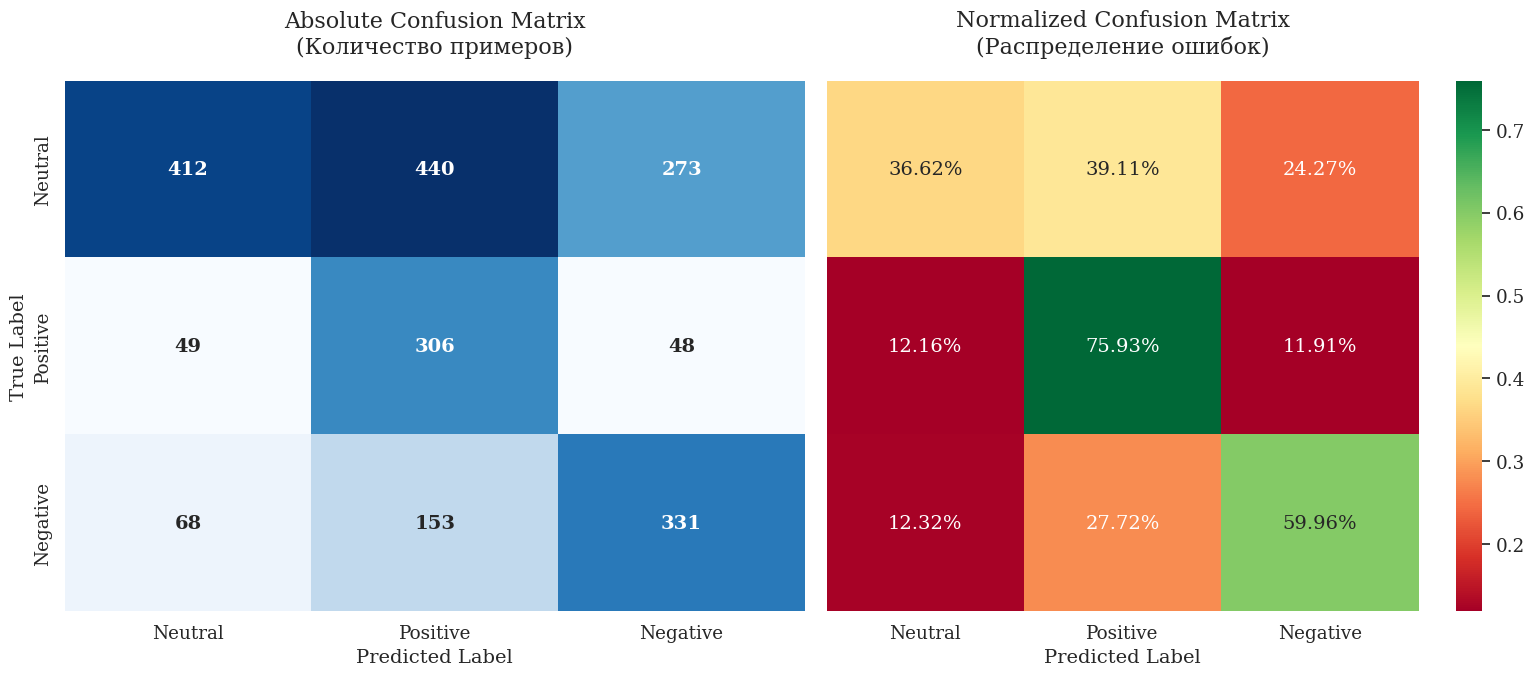

In [17]:
sns.set_theme(style="white", font_scale=1.2)
plt.rcParams['font.family'] = 'serif' # Имитация Times New Roman для ГОСТ

def plot_advanced_confusion_matrix(y_true, y_pred, classes):
    """
    Строит двойную матрицу ошибок: в абсолютных числах и в процентах.
    """
    # Вычисление матриц
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # 1. Абсолютные значения
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=classes, yticklabels=classes, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    axes[0].set_title('Absolute Confusion Matrix\n(Количество примеров)', fontsize=16, pad=20)
    axes[0].set_xlabel('Predicted Label', fontsize=14)
    axes[0].set_ylabel('True Label', fontsize=14)

    # 2. Нормализованные значения (Recall по диагонали)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
                xticklabels=classes, yticklabels=classes, cbar=True,
                annot_kws={"size": 14})
    axes[1].set_title('Normalized Confusion Matrix\n(Распределение ошибок)', fontsize=16, pad=20)
    axes[1].set_xlabel('Predicted Label', fontsize=14)
    axes[1].set_yticks([]) # Убираем дублирование меток слева

    plt.tight_layout()

    # Сохранение в высоком качестве
    plt.savefig('gemma_zeroshot_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

# Запуск визуализации
# Убедитесь, что y_true и y_pred из предыдущего шага доступны
target_names = ["Neutral", "Positive", "Negative"]
plot_advanced_confusion_matrix(y_true, y_pred, target_names)